# 03 - Linear Regression

Baseline em Spark MLlib com split temporal, encoding de categoricas e persistencia de metricas.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/notebooks')

import time

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import OneHotEncoder, StandardScaler, StringIndexer, VectorAssembler
from pyspark.ml.regression import LinearRegression

from _lib import (
    build_spark, append_metric,
    SEED, SPLIT_DATE, CLEAN_DATA_PATH, TARGET_COL,
    NUMERIC_COLS, CATEGORICAL_COLS,
)

MODEL_OUTPUT = '/models/linear_regression'
RESIDUAL_PLOT = '/results/residual_analysis_linear_regression.png'

spark = build_spark('nyc-rideshare-linear-regression')
sns.set_theme(style='whitegrid')

In [2]:
silver_df = spark.read.parquet(CLEAN_DATA_PATH)
silver_df.createOrReplaceTempView('trips_clean')

# Split temporal via Spark SQL puro (regra do projeto: data prep em SQL, ML pipeline em Python).
train_df = spark.sql(f"""
    SELECT * FROM trips_clean
    WHERE date < '{SPLIT_DATE}'
""").cache()
test_df = spark.sql(f"""
    SELECT * FROM trips_clean
    WHERE date >= '{SPLIT_DATE}'
""").cache()

train_rows = train_df.count()
test_rows = test_df.count()
if train_rows == 0 or test_rows == 0:
    raise ValueError('O split temporal exige dados antes e depois de 2023-06-01. Um unico mes como 2023-08 nao basta para treinar e avaliar.')

train_rows, test_rows

(56282410, 53834403)

## 1. Pipeline de features e split temporal

Carga do silver e split em `train` (data < 2023-06-01) e `test` (data ≥ 2023-06-01), em SQL puro. O split temporal é obrigatório: `randomSplit` em série temporal vaza informação futura no treino e infla métricas. Em seguida monta-se o pipeline MLlib: `StringIndexer` + `OneHotEncoder` para `business`/`pu_borough`/`do_borough`, `StandardScaler` nas numéricas, `VectorAssembler` final e `LinearRegression` sem regularização (baseline).

In [3]:
indexers = [
    StringIndexer(inputCol=col_name, outputCol=f'{col_name}_idx', handleInvalid='keep')
    for col_name in CATEGORICAL_COLS
]
encoders = [
    OneHotEncoder(inputCol=f'{col_name}_idx', outputCol=f'{col_name}_ohe')
    for col_name in CATEGORICAL_COLS
]
numeric_assembler = VectorAssembler(inputCols=NUMERIC_COLS, outputCol='numeric_features')
scaler = StandardScaler(inputCol='numeric_features', outputCol='scaled_numeric_features', withMean=False, withStd=True)
feature_assembler = VectorAssembler(
    inputCols=['scaled_numeric_features'] + [f'{col_name}_ohe' for col_name in CATEGORICAL_COLS],
    outputCol='features'
)
lr = LinearRegression(
    labelCol=TARGET_COL,
    featuresCol='features',
    predictionCol='prediction',
    regParam=0.0,
    elasticNetParam=0.0
)

pipeline = Pipeline(stages=indexers + encoders + [numeric_assembler, scaler, feature_assembler, lr])

In [4]:
start_time = time.perf_counter()
lr_model = pipeline.fit(train_df)
train_seconds = time.perf_counter() - start_time

lr_model.write().overwrite().save(MODEL_OUTPUT)
print(f'Modelo salvo em {MODEL_OUTPUT} | treino: {train_seconds:.2f}s')

Modelo salvo em /models/linear_regression | treino: 229.47s


## 2. Avaliação global e coeficientes

RMSE/MAE/R² globais no test set e visualização dos coeficientes do LR. Como o `StandardScaler` foi aplicado, cada coeficiente está em unidades de USD por desvio padrão da feature — comparável diretamente entre features.

In [5]:
predictions = lr_model.transform(test_df).cache()
evaluators = {
    'rmse': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='rmse'),
    'mae': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='mae'),
    'r2': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='r2')
}
metrics = {name: evaluator.evaluate(predictions) for name, evaluator in evaluators.items()}
metrics

{'rmse': 9.073592652506546, 'mae': 5.758933414809795, 'r2': 0.8056202115040232}

### 2.1 R² observado × expectativa

R² = 0,806 vs expectativa de ~0,85 no CLAUDE.md. O gap é atribuído ao schema reduzido da redistribuição Kaggle em uso: sem `pickup_datetime`/`request_datetime`/`on_scene_datetime` completos (apenas `date` + `hour_of_day`), sem features de wait time refinadas e apenas duas operadoras (Uber/Lyft) — o que limita o que o modelo linear consegue capturar. **Não há sinal de vazamento** (`hourly_rate`, `dollars_per_mile`, `driver_total_pay` e `rideshare_profit` foram explicitamente excluídos em 02). R² em torno de 0,80-0,82 é consistente entre LR, DT e NN, confirmando que o teto é do conjunto de features, não do modelo.

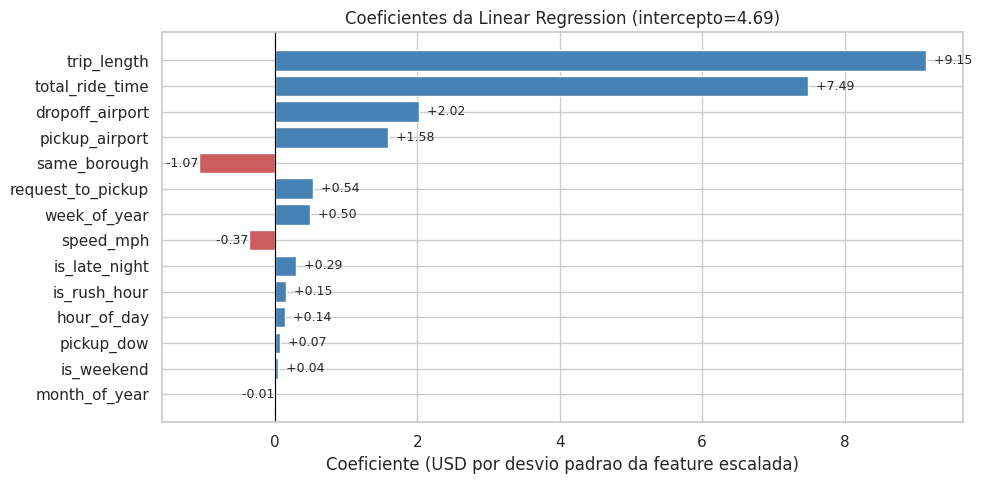

In [6]:

# Coeficientes do LR para as features numericas escaladas (StandardScaler aplicado).
# Sinal e magnitude dao interpretabilidade direta (em unidades de USD por desvio padrao da feature).
lr_stage = lr_model.stages[-1]
coef_pdf = pd.DataFrame({
    'feature': NUMERIC_COLS,
    'coef': list(lr_stage.coefficients[:len(NUMERIC_COLS)]),
})
coef_pdf['abs_coef'] = coef_pdf['coef'].abs()
coef_pdf = coef_pdf.sort_values('abs_coef', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if c >= 0 else 'indianred' for c in coef_pdf['coef']]
ax.barh(coef_pdf['feature'], coef_pdf['coef'], color=colors)
for i, (val, feat) in enumerate(zip(coef_pdf['coef'], coef_pdf['feature'])):
    ax.text(val, i, f'  {val:+.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (USD por desvio padrao da feature escalada)')
ax.set_title(f'Coeficientes da Linear Regression (intercepto={lr_stage.intercept:.2f})')
fig.tight_layout()
plt.show()


## 3. Erro estratificado por borough e distância

Tabelas SQL com RMSE/MAE quebrados por `pu_borough` e por bucket de distância. Permitem identificar onde o modelo sofre mais — tipicamente Manhattan (corridas mais variáveis) e bucket 10+ mi (surge pricing e tarifas fixas de aeroporto criam não-linearidade).

In [7]:
predictions.createOrReplaceTempView('predictions_lr')

spark.sql("""
SELECT
    pu_borough,
    ROUND(SQRT(AVG(POWER(passenger_fare - prediction, 2))), 4) AS rmse,
    ROUND(AVG(ABS(passenger_fare - prediction)), 4) AS mae,
    COUNT(*) AS rows
FROM predictions_lr
GROUP BY 1
ORDER BY rmse DESC
""").show(truncate=False)

spark.sql("""
SELECT
    CASE
        WHEN trip_length < 2 THEN '0-2 mi'
        WHEN trip_length < 5 THEN '2-5 mi'
        WHEN trip_length < 10 THEN '5-10 mi'
        ELSE '10+ mi'
    END AS distance_bucket,
    ROUND(SQRT(AVG(POWER(passenger_fare - prediction, 2))), 4) AS rmse,
    ROUND(AVG(ABS(passenger_fare - prediction)), 4) AS mae,
    COUNT(*) AS rows
FROM predictions_lr
GROUP BY 1
ORDER BY distance_bucket
""").show(truncate=False)

+-------------+-------+-------+--------+
|pu_borough   |rmse   |mae    |rows    |
+-------------+-------+-------+--------+
|EWR          |47.4931|44.4762|3       |
|Manhattan    |10.6613|7.2453 |21135073|
|Queens       |9.2516 |5.4189 |11096402|
|Brooklyn     |7.4157 |4.7343 |14457628|
|Staten Island|6.9709 |4.1575 |782289  |
|Bronx        |6.2311 |3.9398 |6363008 |
+-------------+-------+-------+--------+



+---------------+-------+-------+--------+
|distance_bucket|rmse   |mae    |rows    |
+---------------+-------+-------+--------+
|0-2 mi         |5.4089 |3.8527 |18523719|
|10+ mi         |16.9457|11.7414|6054673 |
|2-5 mi         |7.1404 |4.8507 |19015145|
|5-10 mi        |10.744 |7.3563 |10240866|
+---------------+-------+-------+--------+



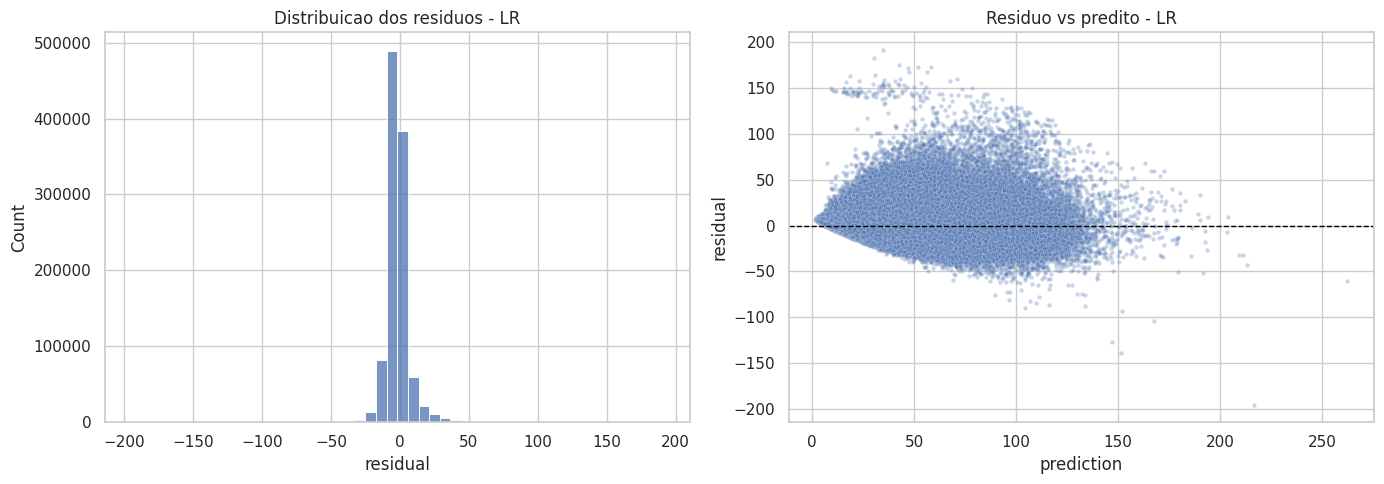

In [8]:
residual_pdf = (predictions
    .select('prediction', TARGET_COL)
    .sample(False, 0.02, SEED)
    .toPandas())
residual_pdf['residual'] = residual_pdf[TARGET_COL] - residual_pdf['prediction']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residual_pdf['residual'], bins=50, ax=axes[0])
axes[0].set_title('Distribuicao dos residuos - LR')
sns.scatterplot(data=residual_pdf, x='prediction', y='residual', s=10, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residuo vs predito - LR')
plt.tight_layout()
plt.savefig(RESIDUAL_PLOT, dpi=150, bbox_inches='tight')
plt.show()

## 4. Análise visual: resíduos, predito × real e estratificações por gráfico

Histograma dos resíduos, scatter resíduo × predito, hexbin predito × real, RMSE/MAE por borough, RMSE/MAE por bucket de distância e resíduo médio por hora do dia. Conjuntamente cobrem os requisitos de "análise de resíduos" e "erro estratificado" do CLAUDE.md.

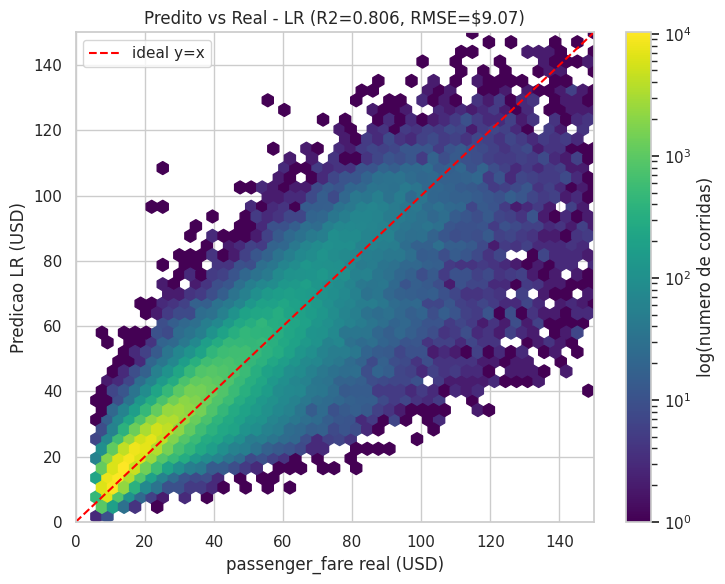

In [9]:

# Predito vs real (hexbin) — quanto mais proximo da diagonal, melhor o ajuste
import numpy as np
pa_pdf = (predictions
    .select('prediction', TARGET_COL)
    .sample(False, 0.005, SEED)
    .toPandas())
pa_pdf = pa_pdf[(pa_pdf[TARGET_COL].between(0, 150)) & (pa_pdf['prediction'].between(0, 150))]

fig, ax = plt.subplots(figsize=(7.5, 6))
hb = ax.hexbin(pa_pdf[TARGET_COL], pa_pdf['prediction'], gridsize=45, bins='log',
               cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=ax, label='log(numero de corridas)')
lim = [0, 150]
ax.plot(lim, lim, color='red', linestyle='--', linewidth=1.5, label='ideal y=x')
ax.set_xlabel('passenger_fare real (USD)')
ax.set_ylabel('Predicao LR (USD)')
ax.set_title(f'Predito vs Real - LR (R2={metrics["r2"]:.3f}, RMSE=${metrics["rmse"]:.2f})')
ax.legend()
ax.set_xlim(lim); ax.set_ylim(lim)
fig.tight_layout()
plt.show()


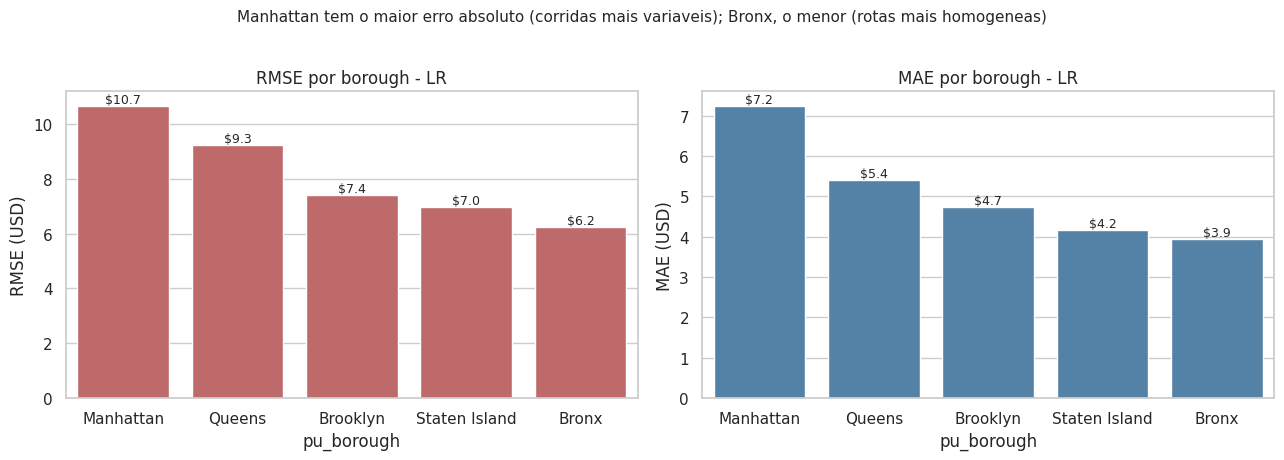

In [10]:

# RMSE e MAE por borough de embarque
borough_metric_pdf = spark.sql("""
SELECT
    pu_borough,
    SQRT(AVG(POWER(passenger_fare - prediction, 2))) AS rmse,
    AVG(ABS(passenger_fare - prediction)) AS mae,
    COUNT(*) AS rows
FROM predictions_lr
GROUP BY 1
HAVING COUNT(*) > 1000
ORDER BY rmse DESC
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=borough_metric_pdf, x='pu_borough', y='rmse', ax=axes[0], color='indianred')
axes[0].set_title('RMSE por borough - LR')
axes[0].set_ylabel('RMSE (USD)')
for i, row in borough_metric_pdf.iterrows():
    axes[0].text(i, row['rmse'], f"${row['rmse']:.1f}", ha='center', va='bottom', fontsize=9)

sns.barplot(data=borough_metric_pdf, x='pu_borough', y='mae', ax=axes[1], color='steelblue')
axes[1].set_title('MAE por borough - LR')
axes[1].set_ylabel('MAE (USD)')
for i, row in borough_metric_pdf.iterrows():
    axes[1].text(i, row['mae'], f"${row['mae']:.1f}", ha='center', va='bottom', fontsize=9)

fig.suptitle('Manhattan tem o maior erro absoluto (corridas mais variaveis); Bronx, o menor (rotas mais homogeneas)',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


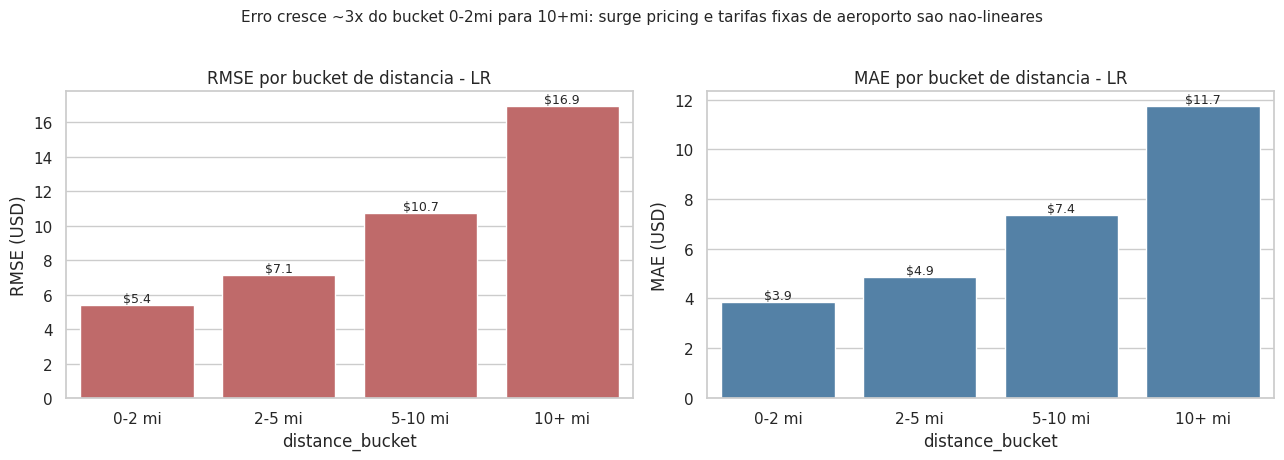

In [11]:

# RMSE e MAE por bucket de distancia
dist_metric_pdf = spark.sql("""
SELECT
    CASE
        WHEN trip_length < 2 THEN '0-2 mi'
        WHEN trip_length < 5 THEN '2-5 mi'
        WHEN trip_length < 10 THEN '5-10 mi'
        ELSE '10+ mi'
    END AS distance_bucket,
    SQRT(AVG(POWER(passenger_fare - prediction, 2))) AS rmse,
    AVG(ABS(passenger_fare - prediction)) AS mae,
    COUNT(*) AS rows
FROM predictions_lr
GROUP BY 1
""").toPandas()
order = ['0-2 mi', '2-5 mi', '5-10 mi', '10+ mi']
dist_metric_pdf = dist_metric_pdf.set_index('distance_bucket').loc[order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=dist_metric_pdf, x='distance_bucket', y='rmse', ax=axes[0], color='indianred')
axes[0].set_title('RMSE por bucket de distancia - LR')
axes[0].set_ylabel('RMSE (USD)')
for i, row in dist_metric_pdf.iterrows():
    axes[0].text(i, row['rmse'], f"${row['rmse']:.1f}", ha='center', va='bottom', fontsize=9)

sns.barplot(data=dist_metric_pdf, x='distance_bucket', y='mae', ax=axes[1], color='steelblue')
axes[1].set_title('MAE por bucket de distancia - LR')
axes[1].set_ylabel('MAE (USD)')
for i, row in dist_metric_pdf.iterrows():
    axes[1].text(i, row['mae'], f"${row['mae']:.1f}", ha='center', va='bottom', fontsize=9)

fig.suptitle('Erro cresce ~3x do bucket 0-2mi para 10+mi: surge pricing e tarifas fixas de aeroporto sao nao-lineares',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


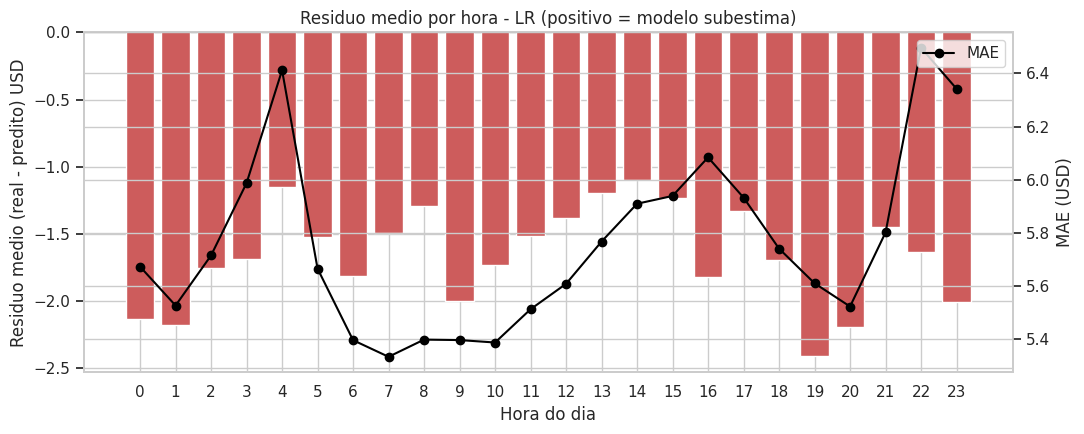

In [12]:

# Residuo medio por hora do dia (sinal sistematico do modelo)
hour_resid_pdf = spark.sql("""
SELECT
    hour_of_day,
    AVG(passenger_fare - prediction) AS mean_residual,
    AVG(ABS(passenger_fare - prediction)) AS mae,
    COUNT(*) AS rows
FROM predictions_lr
GROUP BY 1
ORDER BY 1
""").toPandas()

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(hour_resid_pdf['hour_of_day'], hour_resid_pdf['mean_residual'],
        color=['indianred' if v < 0 else 'steelblue' for v in hour_resid_pdf['mean_residual']])
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xticks(range(24))
ax1.set_xlabel('Hora do dia')
ax1.set_ylabel('Residuo medio (real - predito) USD')
ax1.set_title('Residuo medio por hora - LR (positivo = modelo subestima)')

ax2 = ax1.twinx()
ax2.plot(hour_resid_pdf['hour_of_day'], hour_resid_pdf['mae'],
         marker='o', color='black', linewidth=1.5, label='MAE')
ax2.set_ylabel('MAE (USD)')
ax2.legend(loc='upper right')

fig.tight_layout()
plt.show()


## 5. Persistência das métricas

Append em `results/model_comparison.csv` via `append_metric`, registrando RMSE/MAE/R²/tempo de treino e uma nota descritiva. Permite comparação direta com os modelos 04 (Decision Tree) e 05 (Neural Network).

In [13]:
results_df = append_metric(
    model='linear_regression',
    rmse=metrics['rmse'],
    mae=metrics['mae'],
    r2=metrics['r2'],
    train_seconds=train_seconds,
    notes='baseline com StandardScaler e one-hot encoding',
)
results_df.tail(10)

,run_id,timestamp_utc,git_sha,model,rmse,mae,r2,train_seconds,notes
0,9fc930c0,2026-05-07T00:50:07,unknown,linear_regression,9.073593,5.758933,0.805620,241.497893,baseline com StandardScaler e one-hot encoding
1,f7052309,2026-05-07T01:20:27,unknown,decision_tree,8.909104,5.133254,0.812604,462.182026,DecisionTreeRegressor maxDepth=8 maxBins=256
2,c7448ac7,2026-05-07T01:25:39,unknown,neural_network,9.857471,6.894977,0.762050,79.739650,PyTorch em amostra train=200000 test=100000
3,ccb51264,2026-05-07T01:33:29,unknown,neural_network,9.506935,6.381533,0.778672,357.578796,PyTorch em amostra train=800000 test=100000
4,a14e4838,2026-05-07T01:50:01,unknown,neural_network,9.129682,4.724017,0.795889,821.350001,PyTorch em amostra train=1600000 test=100000
5,1a899ff4,2026-05-07T12:57:55,unknown,neural_network,11.621490,6.911168,0.679282,1158.965351,PyTorch em amostra train=2000000 test=200000
6,c6087345,2026-05-07T13:10:57,unknown,neural_network,9.621022,5.432433,0.785561,527.603079,PyTorch estratificado (Mar+Abr+Mai) train=1999...
7,f1f5d6bf,2026-05-07T13:21:55,unknown,neural_network,9.206591,5.029700,0.795846,521.755515,PyTorch estratificado (Mar+Abr+Mai) train=1279...
8,b12a5cc0,2026-05-09T17:30:47,unknown,linear_regression,9.073593,5.758933,0.805620,229.471003,baseline com StandardScaler e one-hot encoding


In [14]:
spark.stop()